# Are you at a risk of getting heart disease?
## Heart Disease Visualization and Prediction using 6 Models
Dataset in the Folder

## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore") # helps to ignore warnings if they come up

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

## Features (from the Dataset Page)
- age: Age of the patient
- sex: Sex of the patient
- cp: Chest pain type, 0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic
- trtbps: Resting blood pressure (in mm Hg)
- chol: Cholestoral in mg/dl fetched via BMI sensor
- fbs: (fasting blood sugar > 120 mg/dl), 1 = True, 0 = False
- restecg: Resting electrocardiographic results, 0 = Normal, 1 = ST-T wave normality, 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria
- thalachh: Maximum heart rate achieved
- oldpeak: Previous peak
- slp: Slope
- caa: Number of major vessels
- thall: Thalium Stress Test result, (0-3)
- exng: Exercise induced angina, 1 = Yes, 0 = No
- output: 0 = less chance of heart attack, 1 = more chance of heart attack

### What conditions will lead to a higher chance of getting a heart attack?
##### We will only form hypotheses for the 7 most common variables in the list of features
- Age: 60 - 70
- Chest pain type: Atypical Angina
- Resting Blood Pressure: 100 or above
- Cholesterol level: 250 or above
- Electrocardiograph: showing probable or definite left ventricular hypertrophy by Estes' criteria (value 2)
- Maximum Heart Rate: 170 - 180
- Thalium Stress Test Result: 3

## Loading the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
data = pd.read_csv('heart.csv') # reading in the dataset
data.head() # displaying the first 5 rows

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df1 = data.copy() # copying the same dataset to use
df1

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## Preprossesing the data (finding bad values)

In [ ]:
df1.info() # tells us the type of data (in this case we have mostly ints and one column with floats). 
#Also tells us if there are any missing values in our dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df1.shape # size: rows, columns

(303, 14)

In [ ]:
df1[df1.duplicated()] # looking at which row is duplicated

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [ ]:
df1.drop_duplicates(inplace = True) # dropping duplicated rows
df1.reset_index(drop = True, inplace = True)
df1.shape # the new shape shows that we lost a row

(302, 14)

In [ ]:
# turning some of the categorical values we have into words so we can understand what they mean
# doing this allows us to plot them more easily in seaborn to observe the values
df1['sex'] = df1['sex'].map({1: "male", 0: "female"})
df1['exng'] = df1['exng'].map({1: "yes", 0: "no"})
df1['cp'] = df1['cp'].map({0: "typical angina", 1: "atypical angina", 2: "non-anginal pain", 3: "asymptomatic"})
df1['fbs'] = df1['fbs'].map({1: 'true', 0: 'false'})
df1['restecg'] = df1['restecg'].map({0: "normal", 1: "having ST-T wave abnormality", 2: "showing probable or definite left ventricular hypertrophy"})
df1['output'] = df1['output'].map({0: "less chance of heart attack", 1: "more chance of heart attack"})
df1.sample(5) # 5 random rows

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
23,61,male,non-anginal pain,150,243,true,having ST-T wave abnormality,137,yes,1.0,1,0,2,more chance of heart attack
213,56,male,typical angina,125,249,true,normal,144,yes,1.2,1,1,2,less chance of heart attack
253,59,male,asymptomatic,160,273,false,normal,125,no,0.0,2,0,2,less chance of heart attack
152,64,male,asymptomatic,170,227,false,normal,155,no,0.6,1,0,3,more chance of heart attack
41,48,male,atypical angina,130,245,false,normal,180,no,0.2,1,0,2,more chance of heart attack


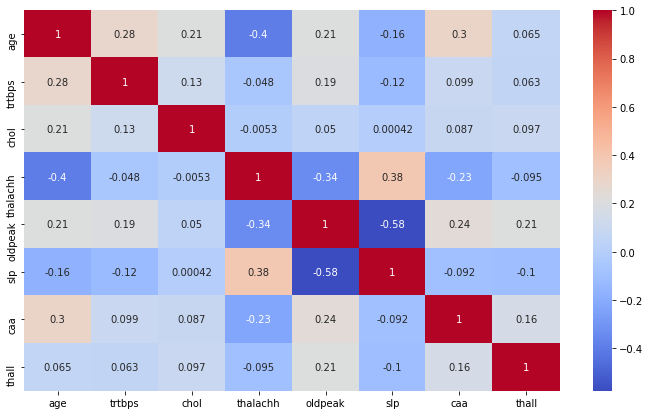

In [ ]:
plt.figure(figsize = (12, 7)) # changing the size of the figure
sns.heatmap(df1.corr(), annot = True, cmap = 'coolwarm') 
# creating a correlation matrix to see how closely related the individual variables are to one another
# other possible cmap's include: Pastel1 and twilight
plt.show()  

## Countplot

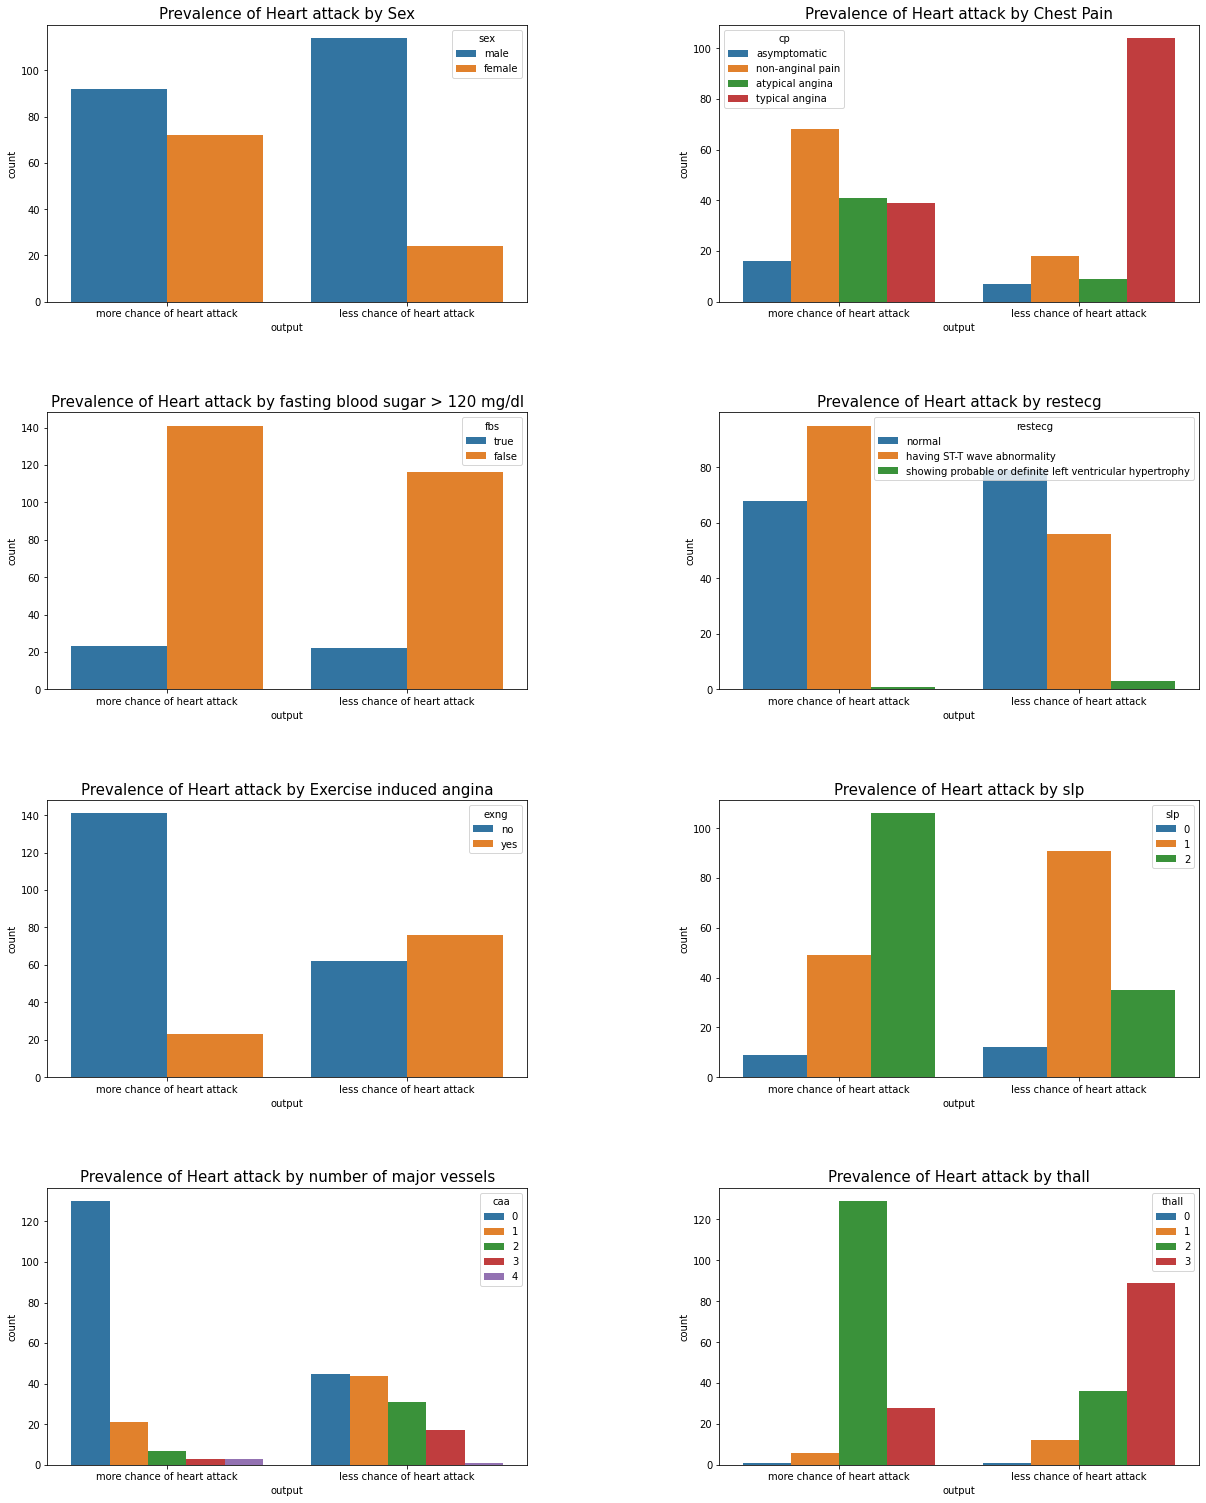

In [ ]:
plt.figure(figsize = (20, 25)) # increased size, making 8 subplots here
plt.subplots_adjust(left = 0.1, bottom = 0.1, right = 0.9, top = 0.9, wspace = 0.4, hspace = 0.4)

plt.subplot(4, 2, 1)
plt.title('Prevalence of Heart attack by Sex', fontsize = 15)
sns.countplot(df1['output'], hue = df1['sex'])

plt.subplot(4, 2, 2)
plt.title('Prevalence of Heart attack by Chest Pain', fontsize = 15)
sns.countplot(df1['output'], hue = df1['cp'])

plt.subplot(4, 2, 3)
plt.title('Prevalence of Heart attack by fasting blood sugar > 120 mg/dl', fontsize = 15)
sns.countplot(df1['output'], hue = df1['fbs'])

plt.subplot(4, 2, 4)
plt.title('Prevalence of Heart attack by restecg', fontsize = 15)
sns.countplot(df1['output'], hue = df1['restecg'])

plt.subplot(4, 2, 5)
plt.title('Prevalence of Heart attack by Exercise induced angina', fontsize = 15)
sns.countplot(df1['output'], hue = df1['exng'])

plt.subplot(4, 2, 6)
plt.title('Prevalence of Heart attack by slp', fontsize = 15)
sns.countplot(df1['output'], hue = df1['slp'])

plt.subplot(4, 2, 7)
plt.title('Prevalence of Heart attack by number of major vessels', fontsize = 15)
sns.countplot(df1['output'], hue = df1['caa'])

plt.subplot(4, 2, 8)
plt.title('Prevalence of Heart attack by thall', fontsize = 15)
sns.countplot(df1['output'], hue = df1['thall'])
plt.show()

## Histplot

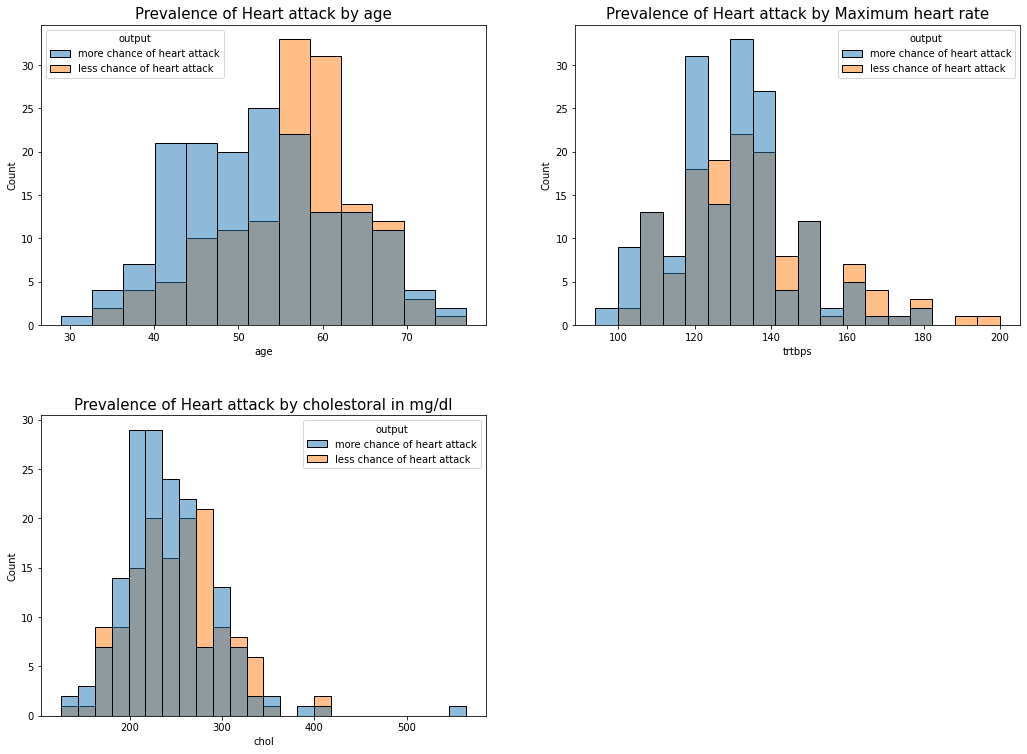

In [ ]:
plt.figure(figsize = (17, 12)) # 3 subplots here
plt.subplots_adjust(left = 0.1, bottom = 0.1, right = 0.9, top = 0.9, wspace = 0.2, hspace = 0.3)

plt.subplot(2, 2, 1)
plt.title('Prevalence of Heart attack by age', fontsize = 15)
sns.histplot(x = df1['age'], hue = df1['output'])

plt.subplot(2, 2, 2)
plt.title('Prevalence of Heart attack by Maximum heart rate', fontsize = 15)
sns.histplot(x = df1['trtbps'], hue = df1['output'])

plt.subplot(2, 2, 3)
plt.title('Prevalence of Heart attack by cholestoral in mg/dl', fontsize = 15)
sns.histplot(x = df1['chol'], hue = df1['output'])
plt.show()

## Jointplot

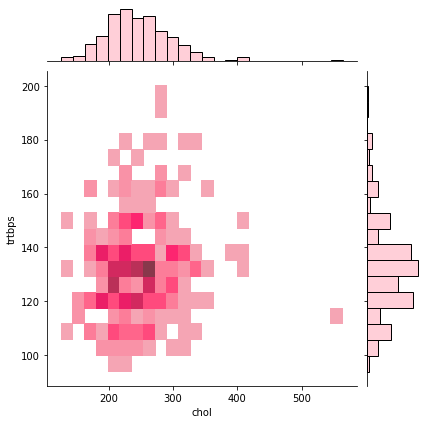

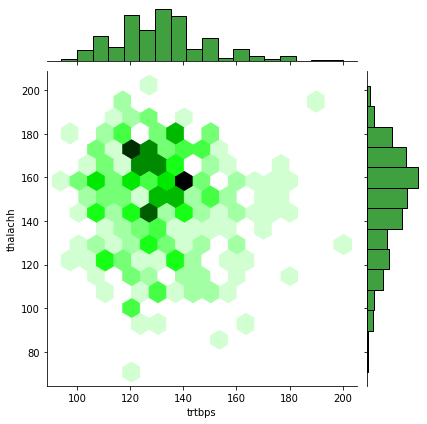

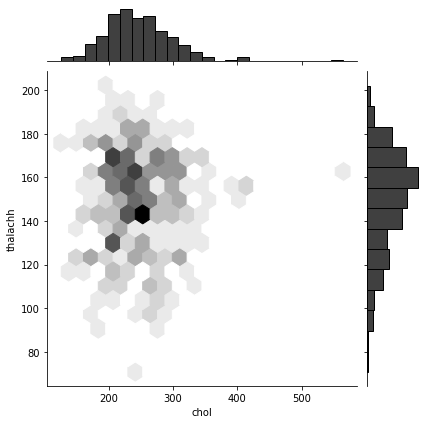

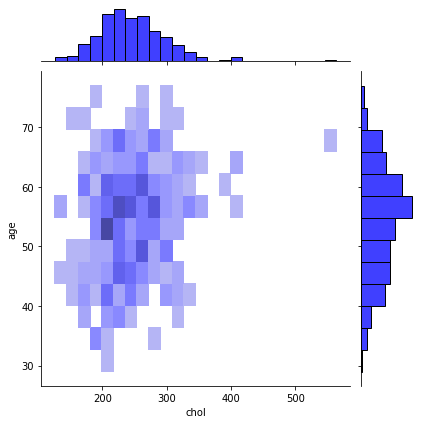

In [ ]:
# combined plots to show where some variables are more likely to occur with others
sns.jointplot(x = df1['chol'], y = df1['trtbps'], kind = 'hist', color = 'pink') 
sns.jointplot(x = df1['trtbps'], y = df1['thalachh'], kind = 'hex', color = 'green')
sns.jointplot(x = df1['chol'], y = df1['thalachh'], kind = 'hex', color = 'black')
sns.jointplot(x = df1['chol'], y = df1['age'], kind = 'hist', color = 'blue')
plt.show()

## Conclusions
#### Common Conditions that leads to more chance of Heart Attack are:
- People of ages 40 to 58
- Chest Pain - Non-anginal 
- Resting Blood Pressure - 120 to 140
- Cholesterol level - 200 to 260
- Electrocardiograph - having ST-T wave normality
- Maximum Heart Rate - above 150
- Thalium Stress Test Result - 2

## Prediction

In [ ]:
df2 = data.copy() # another copied dataset to use for the prediction
df2.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df2.drop_duplicates(inplace = True) # dropping the duplicated values again on the new dataset variable
df2.reset_index(drop = True, inplace = True) # same thing from above
df2.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#### The values in the cell below are the 'baseline' to which the model will be comparing to

In [ ]:
# everything from here on out is going to be numerical. The x values is going to be everything from the 'age' row to the 'thall' row
x = df2.iloc[:, :-1].values 
print(x)

[[63.  1.  3. ...  0.  0.  1.]
 [37.  1.  2. ...  0.  0.  2.]
 [41.  0.  1. ...  2.  0.  2.]
 ...
 [68.  1.  0. ...  1.  2.  3.]
 [57.  1.  0. ...  1.  1.  3.]
 [57.  0.  1. ...  1.  1.  2.]]


In [ ]:
# the y values is just going to be the output variable
y = df2.iloc[:, -1].values
print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]


In [ ]:
# Spliting the data
from sklearn.model_selection import train_test_split

# training size is 80%, testing size is 20% (these values are commonly used from predictions)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0) 

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## The Models and Accuracy of Each

### Brief Explanation of Each Model

* A logistic regression is a model that has a certain number of parameters as input, and with that, it creates an output that is categorical. In our case, this output predicition is 'less or more likely to have heart disease'. In Logistic Regression, it isn't a straight line fit like in linear regression. Instead, it fits a S shaped curve, called a Sigmoid. 
* A KNeigbors classifier is a versatile model that can be used for many things. It 'predicts' by clumping data points that are similar together and finding the distance between the points/clumps.
* An SVC (Support Vector Classifier) is also a model in which data is clustered and organized into groups and evauluated in that way.
* The Decision Tree Classifier is probably the easist to wrap your head around. It is a flowchart-like tree structure where a node represents an attribute and each leaf node represents the outcome. 
* The Random Forest Classifier works similar to Decision Trees. However, instead of searching for the most important feature while splitting a node (like DecisionTrees do), it searches for the best feature among a random subset of features.
* Gradient boosting classifiers are interesting because they are a group of algorithms that combine many weak learning models together to create a stronger predictive model. Decision trees are used for the most part when doing gradient boosting.

In [ ]:
n = ['Logistic Regression', 'KNeighbors Classifier', 'SVC', 'DecisionTree Classifier', 'RandomForest Classifier', 'GradientBoosting Classifier'] # names of the models
v = [LogisticRegression(), KNeighborsClassifier(), SVC(), DecisionTreeClassifier(), RandomForestClassifier(), GradientBoostingClassifier()] # list holding model values
models = dict(zip(n, v))
#print(models)

In [ ]:
predicted = []
for name, val in models.items():
    model = val
    model.fit(x_train, y_train) # fit the x and y training variables
    p = model.predict(x_test) # doing a prediction
    accuracy = accuracy_score(y_test, p) # manufacturing the accuracy for each model
    predicted.append(accuracy)
    print(str(name) + " - " + "Accuracy: " + str(accuracy))

Logistic Regression - Accuracy: 0.8688524590163934
KNeighbors Classifier - Accuracy: 0.9180327868852459
SVC - Accuracy: 0.9344262295081968
DecisionTree Classifier - Accuracy: 0.7704918032786885
RandomForest Classifier - Accuracy: 0.8524590163934426
GradientBoosting Classifier - Accuracy: 0.819672131147541


### As it can be seen on the graph below and the value above, the SVC is the most accurate model
### Make a guess, why do you think the SVC performed so well?

## Accuracy Visualization

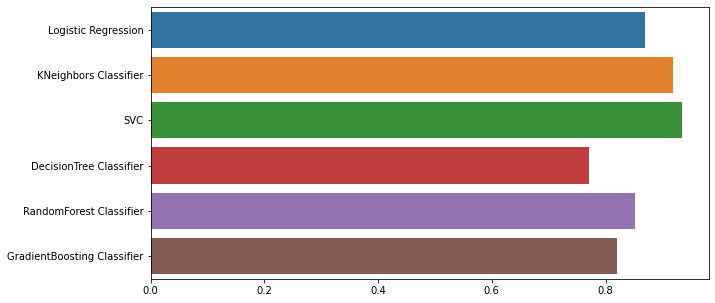

In [ ]:
# let's visualize each accuracy on a bargraph
plt.figure(figsize = (10, 5)) 
sns.barplot(x = predicted, y = n)
plt.show()

In [ ]:
svc = SVC() # creating a new SVC variable
svc.fit(x_train,y_train) # fitting the x and the y
svcP = svc.predict(x_test) # doing the prediction
print("Accuracy:", accuracy_score(y_test, svcP)) # getting the accuracy again

Accuracy: 0.9344262295081968


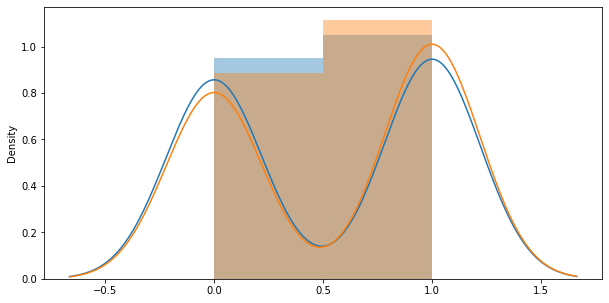

In [ ]:
# with the steps we did in the above cell, we can now plot the predicted values of the SVC with the actual values and see how close they are
# Blue = Predicted, Orange = Actual
plt.figure(figsize = (10, 5))
sns.distplot(svcP, label = 'Predicted')
sns.distplot(y_test, label = 'Actual')
plt.show()